# Bi-probability plots

The classic way to see CP violation: plot $P(\nu_\mu \to \nu_e)$ against $P(\bar\nu_\mu \to \bar\nu_e)$ as the CP phase runs through $2\pi$. The locus is an ellipse, and it collapses to a point on the diagonal when there is nothing to see.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## Neutrinos and antineutrinos

The antineutrino Hamiltonian is the complex conjugate of the neutrino one with the matter potential reversed. Building both and scanning $\delta_{CP}$ gives the ellipse.

In [2]:
def biprobability(energy_gev, baseline_km, vcc, n_phase=400):
    """Returns P(numu->nue) and its antineutrino partner over delta_CP."""
    dcp = np.linspace(0.0, 2.0*np.pi, n_phase)
    p_nu, p_nubar = [], []
    for d in dcp:
        h_vac = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
            gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, d,
            gd.D21_NO_BF, gd.D31_NO_BF)
        h_nu = hamiltonians3nu.hamiltonian_3nu_matter(
            h_vac, energy_gev*GEV, vcc)
        # Antineutrinos: conjugate the Hamiltonian, flip V_CC
        h_bar = hamiltonians3nu.hamiltonian_3nu_matter(
            np.conj(h_vac), energy_gev*GEV, -vcc)
        p_nu.append(oscprob3nu.probabilities_3nu(
            h_nu, baseline_km*KM)[3])
        p_nubar.append(oscprob3nu.probabilities_3nu(
            h_bar, baseline_km*KM)[3])
    return np.array(p_nu), np.array(p_nubar), dcp

## In vacuum

With no matter the ellipse is centred on the diagonal: CP violation moves you along it, but neutrinos and antineutrinos stay symmetric.

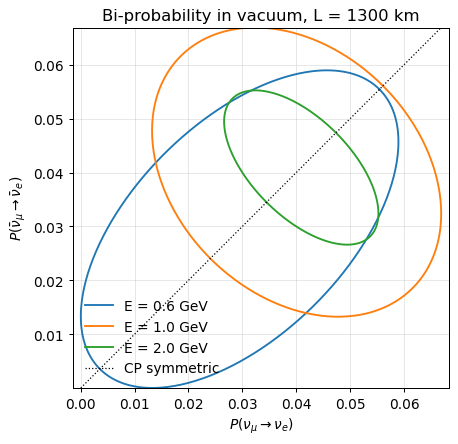

In [3]:
fig, ax = plt.subplots(figsize=(5.4, 5.2))
for e_gev in (0.6, 1.0, 2.0):
    p, pbar, dcp = biprobability(e_gev, 1300.0, 0.0)
    ax.plot(p, pbar, label="E = %.1f GeV" % e_gev)
lims = ax.get_xlim()
ax.plot(lims, lims, "k:", lw=1, label="CP symmetric")
ax.set_xlabel(r"$P(\nu_\mu \to \nu_e)$")
ax.set_ylabel(r"$P(\bar\nu_\mu \to \bar\nu_e)$")
ax.set_title("Bi-probability in vacuum, L = 1300 km")
ax.legend()
ax.set_aspect("equal", adjustable="datalim")
plt.show()

## In matter

Matter breaks the symmetry between neutrinos and antineutrinos on its own, and pushes the ellipses off the diagonal. Disentangling that from genuine CP violation is the central difficulty of a long-baseline measurement.

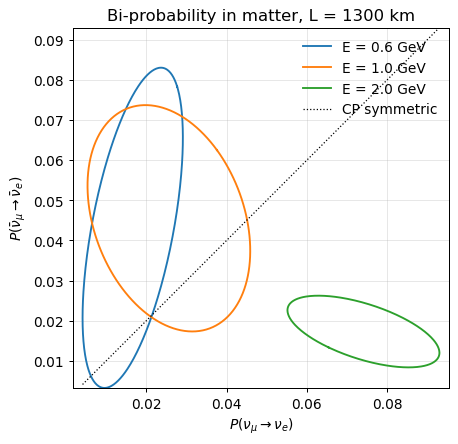

In [4]:
fig, ax = plt.subplots(figsize=(5.4, 5.2))
for e_gev in (0.6, 1.0, 2.0):
    p, pbar, dcp = biprobability(e_gev, 1300.0,
                                 gd.VCC_EARTH_CRUST)
    ax.plot(p, pbar, label="E = %.1f GeV" % e_gev)
lims = ax.get_xlim()
ax.plot(lims, lims, "k:", lw=1, label="CP symmetric")
ax.set_xlabel(r"$P(\nu_\mu \to \nu_e)$")
ax.set_ylabel(r"$P(\bar\nu_\mu \to \bar\nu_e)$")
ax.set_title("Bi-probability in matter, L = 1300 km")
ax.legend()
ax.set_aspect("equal", adjustable="datalim")
plt.show()

## Where on the ellipse

Marking a few values of $\delta_{CP}$ shows which part of the curve corresponds to which phase.

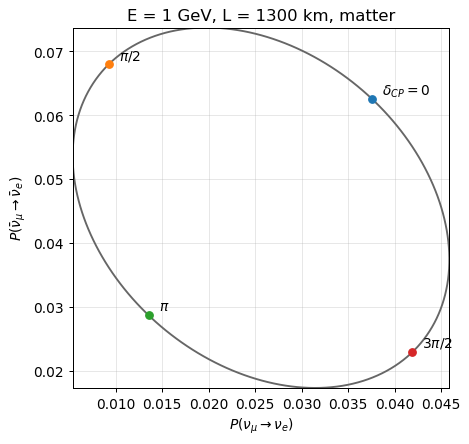

In [5]:
p, pbar, dcp = biprobability(1.0, 1300.0, gd.VCC_EARTH_CRUST)

fig, ax = plt.subplots(figsize=(5.4, 5.2))
ax.plot(p, pbar, color="0.4")
for target, label in ((0.0, r"$\delta_{CP} = 0$"),
                      (np.pi/2, r"$\pi/2$"),
                      (np.pi, r"$\pi$"),
                      (3*np.pi/2, r"$3\pi/2$")):
    k = int(np.argmin(np.abs(dcp-target)))
    ax.plot(p[k], pbar[k], "o")
    ax.annotate(label, (p[k], pbar[k]),
                textcoords="offset points", xytext=(8, 4))
ax.set_xlabel(r"$P(\nu_\mu \to \nu_e)$")
ax.set_ylabel(r"$P(\bar\nu_\mu \to \bar\nu_e)$")
ax.set_title("E = 1 GeV, L = 1300 km, matter")
plt.show()

## What sets the size of the effect

The ellipse is a picture; the number behind it is the **Jarlskog invariant**, the one parametrisation-independent measure of CP violation in the mixing matrix:

$$ J_{CP} = c_{12}s_{12}\,c_{23}s_{23}\,c_{13}^2 s_{13}\,\sin\delta_{CP} . $$

It vanishes if any mixing angle is zero or if $\sin\delta_{CP} = 0$ — and when it does, the vacuum ellipse collapses onto the diagonal and there is nothing to measure. Every CP-odd term in the vacuum probabilities is proportional to it.

`hamiltonians3nu.J` returns the quartic product $U^*_{\alpha k}U_{\beta k}U_{\alpha j}U^*_{\beta j}$, whose imaginary part is $J_{CP}$ up to a sign convention:

In [6]:
def jarlskog(dcp):
    # J_CP from the library quartic product
    U = hamiltonians3nu.pmns_mixing_matrix(
        gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, dcp)
    return -np.imag(hamiltonians3nu.J(U, 0, 1, 0, 1))


def jarlskog_closed_form(dcp):
    # The textbook expression, for comparison
    s12, s23, s13 = gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF
    c12, c23, c13 = [np.sqrt(1.0-s*s)
                     for s in (s12, s23, s13)]
    return c12*s12*c23*s23*c13*c13*s13*np.sin(dcp)


for d in (0.0, np.pi/2, gd.DCP_NO_BF, np.pi):
    print("dCP = %6.1f deg :  J = %+.5e   "
          "(closed form %+.5e)"
          % (np.degrees(d), jarlskog(d),
             jarlskog_closed_form(d)))

dCP =    0.0 deg :  J = -0.00000e+00   (closed form +0.00000e+00)
dCP =   90.0 deg :  J = +3.33765e-02   (closed form +3.33765e-02)
dCP =  217.0 deg :  J = -2.00865e-02   (closed form -2.00865e-02)
dCP =  180.0 deg :  J = +4.08744e-18   (closed form +4.08744e-18)


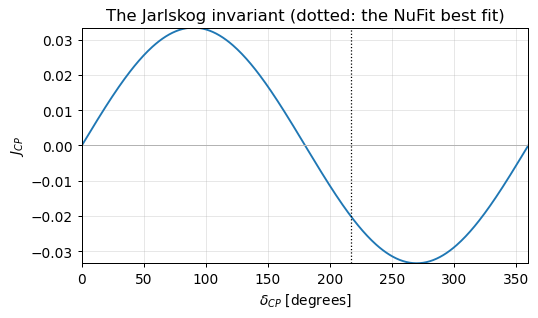

largest |J| over the scan : 3.33762e-02


In [7]:
dcp_scan = np.linspace(0.0, 2.0*np.pi, 400)
J_scan = np.array([jarlskog(d) for d in dcp_scan])

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(np.degrees(dcp_scan), J_scan)
ax.axhline(0.0, color="0.7", lw=0.8)
ax.axvline(np.degrees(gd.DCP_NO_BF), color="k", ls=":",
           lw=1)
ax.set_xlim(0.0, 360.0)
ax.set_xlabel(r"$\delta_{CP}$ [degrees]")
ax.set_ylabel(r"$J_{CP}$")
ax.set_title("The Jarlskog invariant "
             "(dotted: the NuFit best fit)")
plt.show()

print("largest |J| over the scan : %.5e"
      % np.max(np.abs(J_scan)))

The zeros at $\delta_{CP} = 0$ and $180^\circ$ are exactly where the vacuum ellipse degenerates to a point on the diagonal. Note the scale: $J_{CP}$ peaks near $0.033$, small because it carries a factor of $s_{13}$ — the CP-violating effect is suppressed by the smallest mixing angle, which is a large part of why the measurement is hard.

---

**Previous:** [Oscillograms](04_oscillogram.ipynb)  
**Next:** [The Earth: PREM, chords, and slabs](06_earth_and_prem.ipynb) --- how a varying profile becomes a sequence of exact pieces  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)